# InstantX IP-Adapter recovery test

Sanity-ceiling for the new pretrained-adapter pipeline. Feeds the pipeline the **perfect** init latent (VAE-encoded ground-truth stimulus) and the **perfect** SigLIP embedding (ground-truth cache entry), then asks: given a partially-noised version of the init latent, can the adapter-conditioned denoise recover the original?

This is the upper bound. If recovery fails here, nothing with neural-decoded inputs will work downstream. If it succeeds, we know the adapter + init-latent + aperture-compositing path is wired correctly, and any downstream failure lives in the neural decoder, not the generator.

What we sweep:
- `strength` ∈ {0.3, 0.5, 0.7, 0.9} — how much noise is added to the init latent before denoising starts.
- `ip_adapter_scale` ∈ {0.0, 0.5, 1.0} — 0.0 isolates the "unconditional VAE roundtrip + scheduler" path so we can see how much of the recovery is the adapter vs just the init latent bleeding through.
- `aperture_composite` ∈ {True, False} — on/off so we can see the adapter's contribution inside the trained ring separately from the hard-paste of the untrained ring.

In [1]:
import sys
sys.path.insert(0, ".")

import numpy as np
import torch
from PIL import Image

from config_const import SIGLIP_EMBEDDINGS_PATH, RUST_STIM_DIR, N_STIMULI
from generation.flux_instantx import (
    load_pipeline,
    generate_img2img,
    encode_image,
    decode_latent,
)

In [2]:
pipe, image_proj = None, None
torch.cuda.empty_cache()
pipe, image_proj = load_pipeline(device="cuda", default_scale=1.0)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [3]:
# Ground-truth SigLIP cache (300, 1152)
all_embeds = torch.load(SIGLIP_EMBEDDINGS_PATH, weights_only=True)
print(f"SigLIP cache: {tuple(all_embeds.shape)}")

# Pick a handful of stimuli to test
STIM_INDICES = [0, 7, 42, 123]
IMAGE_SIZE = 512

def load_stim(idx: int) -> Image.Image:
    return Image.open(RUST_STIM_DIR / f"{idx:04d}.png").convert("RGB")

stim_pils = [load_stim(i) for i in STIM_INDICES]
stim_embs = [all_embeds[i] for i in STIM_INDICES]
for idx, pil in zip(STIM_INDICES, stim_pils):
    print(f"  stim {idx}: {pil.size}")

SigLIP cache: (300, 1152)
  stim 0: (276, 276)
  stim 7: (276, 276)
  stim 42: (276, 276)
  stim 123: (276, 276)


## VAE round-trip sanity check

Before running the adapter at all, confirm the grayscale-luminance VAE encode/decode is lossless enough that any recovery failure later is due to the adapter or noising, not the VAE itself.

In [4]:
def vae_roundtrip(pil: Image.Image) -> Image.Image:
    init = pil.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
    latent = encode_image(pipe, init)
    return decode_latent(pipe, latent)

for idx, pil in zip(STIM_INDICES, stim_pils):
    rt = vae_roundtrip(pil)
    a = np.array(pil.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)).astype(float)
    # luminance-only compare since encode_image grayscales the input
    a_gray = 0.2989*a[...,0] + 0.5870*a[...,1] + 0.1140*a[...,2]
    b_gray = np.array(rt.convert("L")).astype(float)
    mse = ((a_gray - b_gray) ** 2).mean()
    print(f"stim {idx}: VAE roundtrip grayscale MSE = {mse:.2f}")

stim 0: VAE roundtrip grayscale MSE = 2.30
stim 7: VAE roundtrip grayscale MSE = 2.48
stim 42: VAE roundtrip grayscale MSE = 2.13
stim 123: VAE roundtrip grayscale MSE = 2.57


## Recovery sweep

For one stimulus, sweep (strength × ip_adapter_scale) with aperture compositing **on**. Each cell output is a grid of `(original | recovered)` pairs.

In [5]:
def make_grid(pairs: list[tuple[Image.Image, Image.Image]], label: str, size: int = 256) -> Image.Image:
    """Side-by-side (original | recovered) row with a label strip."""
    from PIL import ImageDraw
    n = len(pairs)
    label_h = 24
    grid = Image.new("RGB", (size * 2 * n, size + label_h), (30, 30, 30))
    draw = ImageDraw.Draw(grid)
    draw.text((8, 4), label, fill=(230, 230, 230))
    for i, (orig, rec) in enumerate(pairs):
        grid.paste(orig.resize((size, size)), (i * size * 2, label_h))
        grid.paste(rec.resize((size, size)),  (i * size * 2 + size, label_h))
    return grid

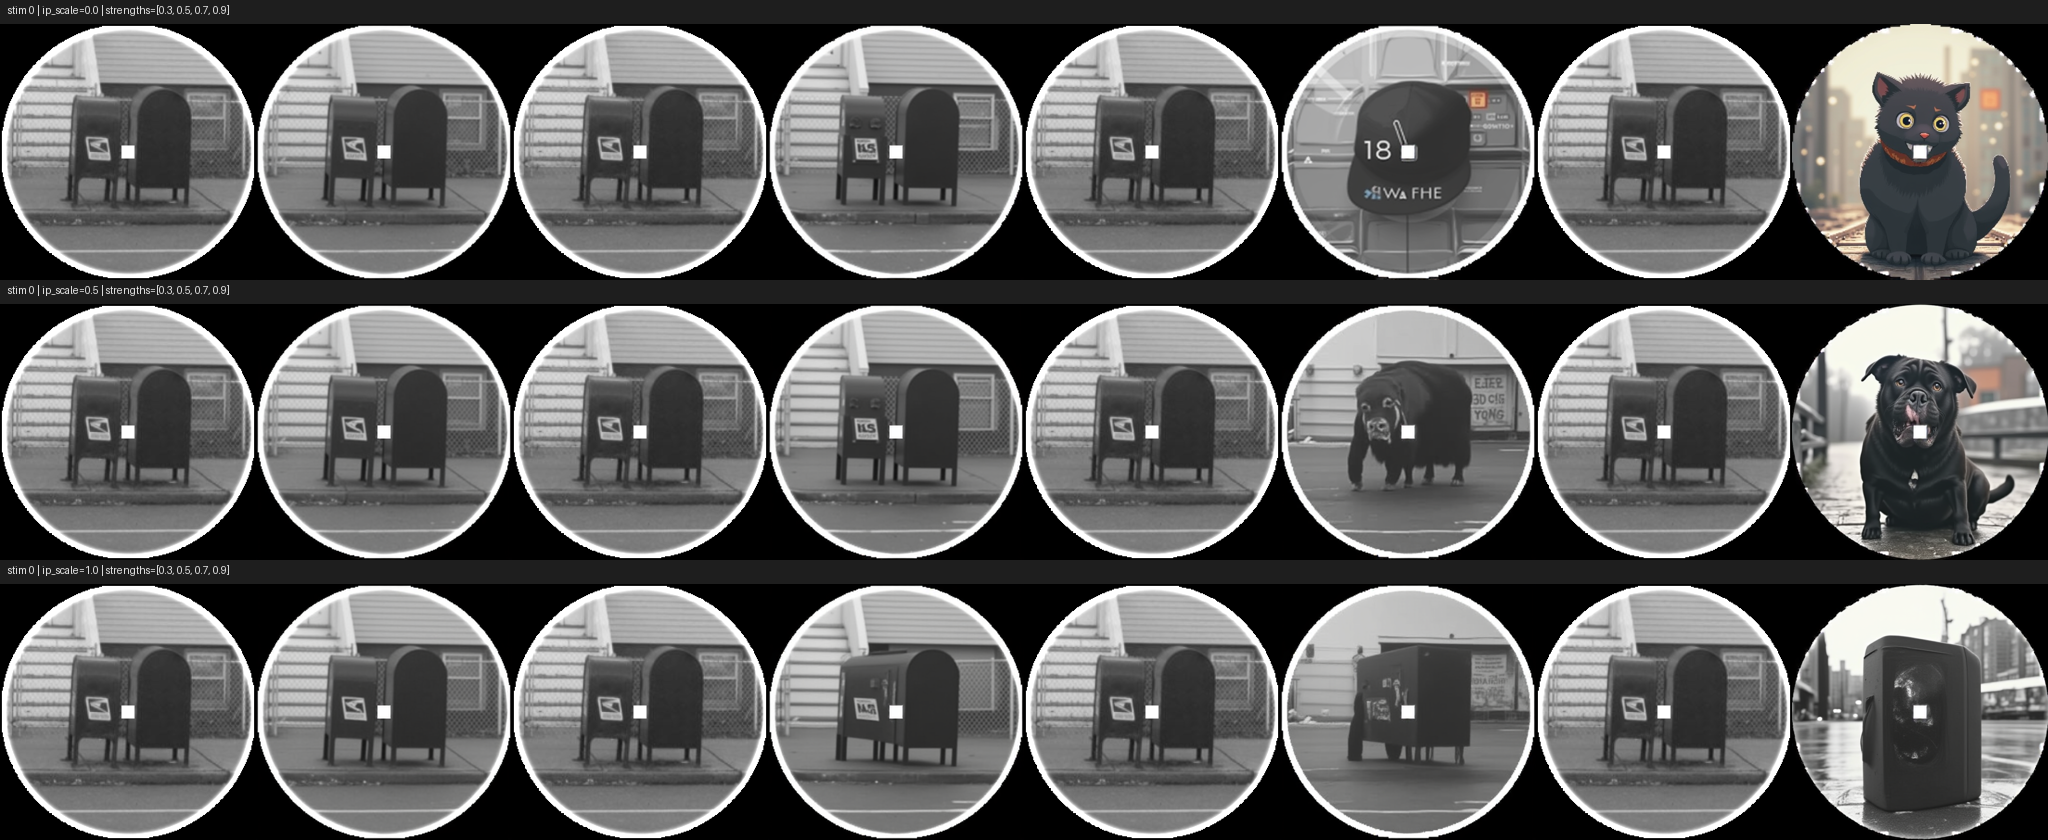

In [6]:
TEST_IDX = 0
init_pil = stim_pils[0]
init_emb = stim_embs[0]

STRENGTHS = [0.3, 0.5, 0.7, 0.9]
IP_SCALES = [0.0, 0.5, 1.0]
NUM_STEPS = 20
SEED = 0

grids = []
for ip_scale in IP_SCALES:
    pairs = []
    for strength in STRENGTHS:
        rec = generate_img2img(
            pipe, image_proj, init_pil, init_emb,
            strength=strength,
            height=IMAGE_SIZE, width=IMAGE_SIZE,
            num_inference_steps=NUM_STEPS,
            guidance_scale=3.5,
            ip_adapter_scale=ip_scale,
            seed=SEED,
            aperture_composite=True,
            show_progress=False,
        )
        pairs.append((init_pil, rec))
    label = f"stim {TEST_IDX} | ip_scale={ip_scale:.1f} | strengths={STRENGTHS}"
    grids.append(make_grid(pairs, label))

full = Image.new("RGB", (grids[0].width, sum(g.height for g in grids)), (20, 20, 20))
y = 0
for g in grids:
    full.paste(g, (0, y))
    y += g.height
full

## Aperture compositing: on vs off

Fix `strength=0.7`, `ip_scale=1.0`. Compare with and without per-step aperture compositing. "off" should let the adapter repaint everywhere including the untrained ring; "on" should keep the untrained ring pinned to the original.

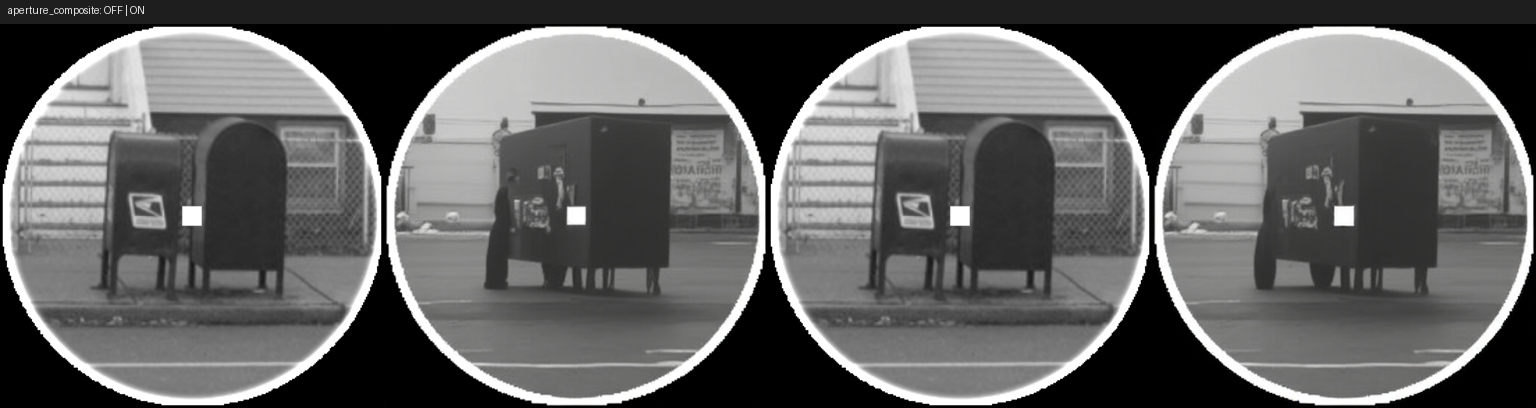

In [7]:
ap_pairs = []
for composite in [False, True]:
    rec = generate_img2img(
        pipe, image_proj, init_pil, init_emb,
        strength=0.7,
        height=IMAGE_SIZE, width=IMAGE_SIZE,
        num_inference_steps=NUM_STEPS,
        guidance_scale=3.5,
        ip_adapter_scale=1.0,
        seed=SEED,
        aperture_composite=composite,
        show_progress=False,
    )
    ap_pairs.append((init_pil, rec))

make_grid(ap_pairs, "aperture_composite: OFF | ON", size=384)

## Multi-stimulus spot check

Fixed settings, multiple stimuli. This is the test to look at when deciding whether the upper-bound recovery is acceptable across the dataset, not just one lucky image.

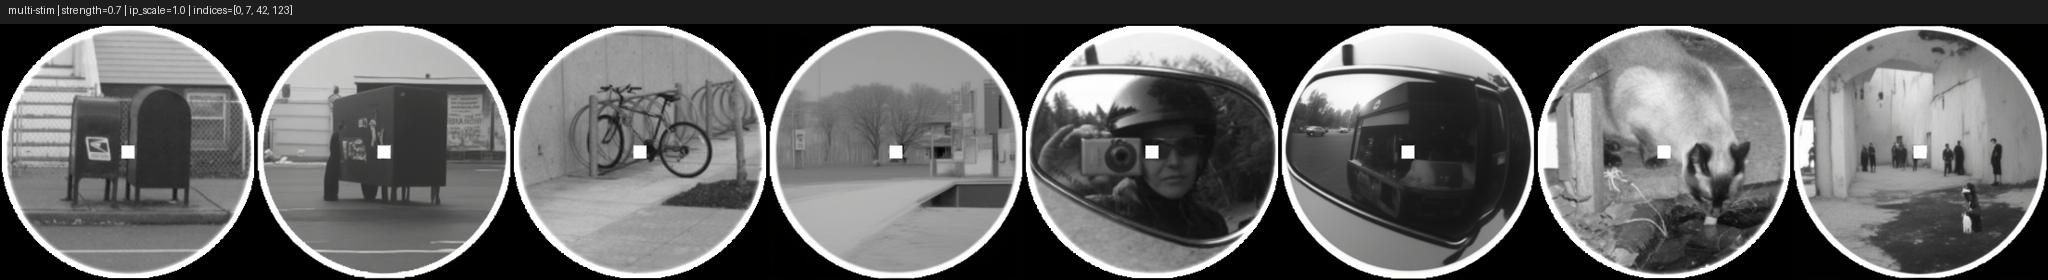

In [8]:
multi_pairs = []
for idx, pil, emb in zip(STIM_INDICES, stim_pils, stim_embs):
    rec = generate_img2img(
        pipe, image_proj, pil, emb,
        strength=0.7,
        height=IMAGE_SIZE, width=IMAGE_SIZE,
        num_inference_steps=NUM_STEPS,
        guidance_scale=3.5,
        ip_adapter_scale=1.0,
        seed=int(idx),
        aperture_composite=True,
        show_progress=False,
    )
    multi_pairs.append((pil, rec))

make_grid(multi_pairs, f"multi-stim | strength=0.7 | ip_scale=1.0 | indices={STIM_INDICES}", size=256)

## Quantitative recovery metric

Luminance MSE inside the trained aperture between the original stimulus and the recovery. Lower is better. We report it at each (strength × ip_scale) combo so we can see where the adapter actually helps vs hurts relative to the init-latent bleed-through.

In [9]:
from generation.aperture import load_packed_aperture_mask

def aperture_pixel_mask(image_size: int) -> np.ndarray:
    """Binary (H, W) mask: 1 inside trained aperture, 0 outside / on fixation."""
    yy, xx = np.meshgrid(np.arange(image_size), np.arange(image_size), indexing="ij")
    c = (image_size - 1) / 2
    r = image_size / 2
    circle = ((yy - c) ** 2 + (xx - c) ** 2) <= r ** 2
    half = int(round(image_size * 0.06 / 2))
    center_sq = np.zeros_like(circle, dtype=bool)
    lo = int(round(c)) - half
    hi = int(round(c)) + half + 1
    center_sq[lo:hi, lo:hi] = True
    return (circle & ~center_sq).astype(np.float32)

pixel_mask = aperture_pixel_mask(IMAGE_SIZE)
mask_sum = pixel_mask.sum()

def masked_lum_mse(orig: Image.Image, rec: Image.Image) -> float:
    a = np.array(orig.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)).astype(np.float32)
    a = 0.2989*a[...,0] + 0.5870*a[...,1] + 0.1140*a[...,2]
    b = np.array(rec.convert("L")).astype(np.float32)
    err = ((a - b) ** 2) * pixel_mask
    return float(err.sum() / mask_sum)

print(f"{'strength':>10} {'ip_scale':>10} {'MSE':>10}")
for strength in STRENGTHS:
    for ip_scale in IP_SCALES:
        rec = generate_img2img(
            pipe, image_proj, init_pil, init_emb,
            strength=strength,
            height=IMAGE_SIZE, width=IMAGE_SIZE,
            num_inference_steps=NUM_STEPS,
            guidance_scale=3.5,
            ip_adapter_scale=ip_scale,
            seed=SEED,
            aperture_composite=True,
            show_progress=False,
        )
        mse = masked_lum_mse(init_pil, rec)
        print(f"{strength:>10.2f} {ip_scale:>10.2f} {mse:>10.2f}")

  strength   ip_scale        MSE
      0.30       0.00      47.27
      0.30       0.50      45.61
      0.30       1.00      45.88
      0.50       0.00     147.88
      0.50       0.50     136.75
      0.50       1.00     155.11
      0.70       0.00     689.28
      0.70       0.50     582.88
      0.70       1.00     531.89
      0.90       0.00    4573.93
      0.90       0.50    4977.12
      0.90       1.00    4263.02


## Text prompt contribution

The IP-Adapter is weak for out-of-distribution grayscale stimuli. The FLUX text encoder is a separate, independently strong conditioning path. We test whether adding text captions as `prompt` recovers semantic content the adapter alone misses.

Four conditions, fixed `strength=0.7`, `ip_scale=1.0`:

- **no text** — empty prompt (current default)
- **short** — short InstructBLIP caption (~10 words)
- **detailed** — detailed InstructBLIP caption (~40-60 words)
- **mean** — average of short and detailed CLIP/T5 embeddings

In [10]:
import json
from config_const import (
    BLIP2_CAPTIONS_PATH, BLIP2_DETAILED_CAPTIONS_PATH,
    CLIP_EMBEDS_PATH, T5_EMBEDS_PATH,
    CLIP_DETAILED_EMBEDS_PATH, T5_DETAILED_EMBEDS_PATH,
)

with open(BLIP2_CAPTIONS_PATH) as f:
    captions_short = json.load(f)
with open(BLIP2_DETAILED_CAPTIONS_PATH) as f:
    captions_detailed = json.load(f)

clip_short    = torch.load(CLIP_EMBEDS_PATH,          weights_only=True)
t5_short      = torch.load(T5_EMBEDS_PATH,            weights_only=True)
clip_detailed = torch.load(CLIP_DETAILED_EMBEDS_PATH, weights_only=True)
t5_detailed   = torch.load(T5_DETAILED_EMBEDS_PATH,   weights_only=True)
clip_mean     = (clip_short + clip_detailed) / 2
t5_mean       = (t5_short   + t5_detailed)   / 2

print(f"short    CLIP {tuple(clip_short.shape)}  T5 {tuple(t5_short.shape)}")
print(f"detailed CLIP {tuple(clip_detailed.shape)}  T5 {tuple(t5_detailed.shape)}")

for idx in STIM_INDICES:
    print(f"\n  stim {idx}")
    print(f"    short:    {captions_short[str(idx)]!r}")
    print(f"    detailed: {captions_detailed[str(idx)]!r}")

   condition   stim        MSE
     no text      7     439.38
     no text     42     629.59
     no text    123     693.84
       short      0     479.19
       short      7     438.64
       short     42     605.69
       short    123     712.64
    detailed      0     487.94
    detailed      7     443.63
    detailed     42     602.84
    detailed    123     739.95
        mean      0     471.39
        mean      7     432.64
        mean     42     647.73
        mean    123     755.79


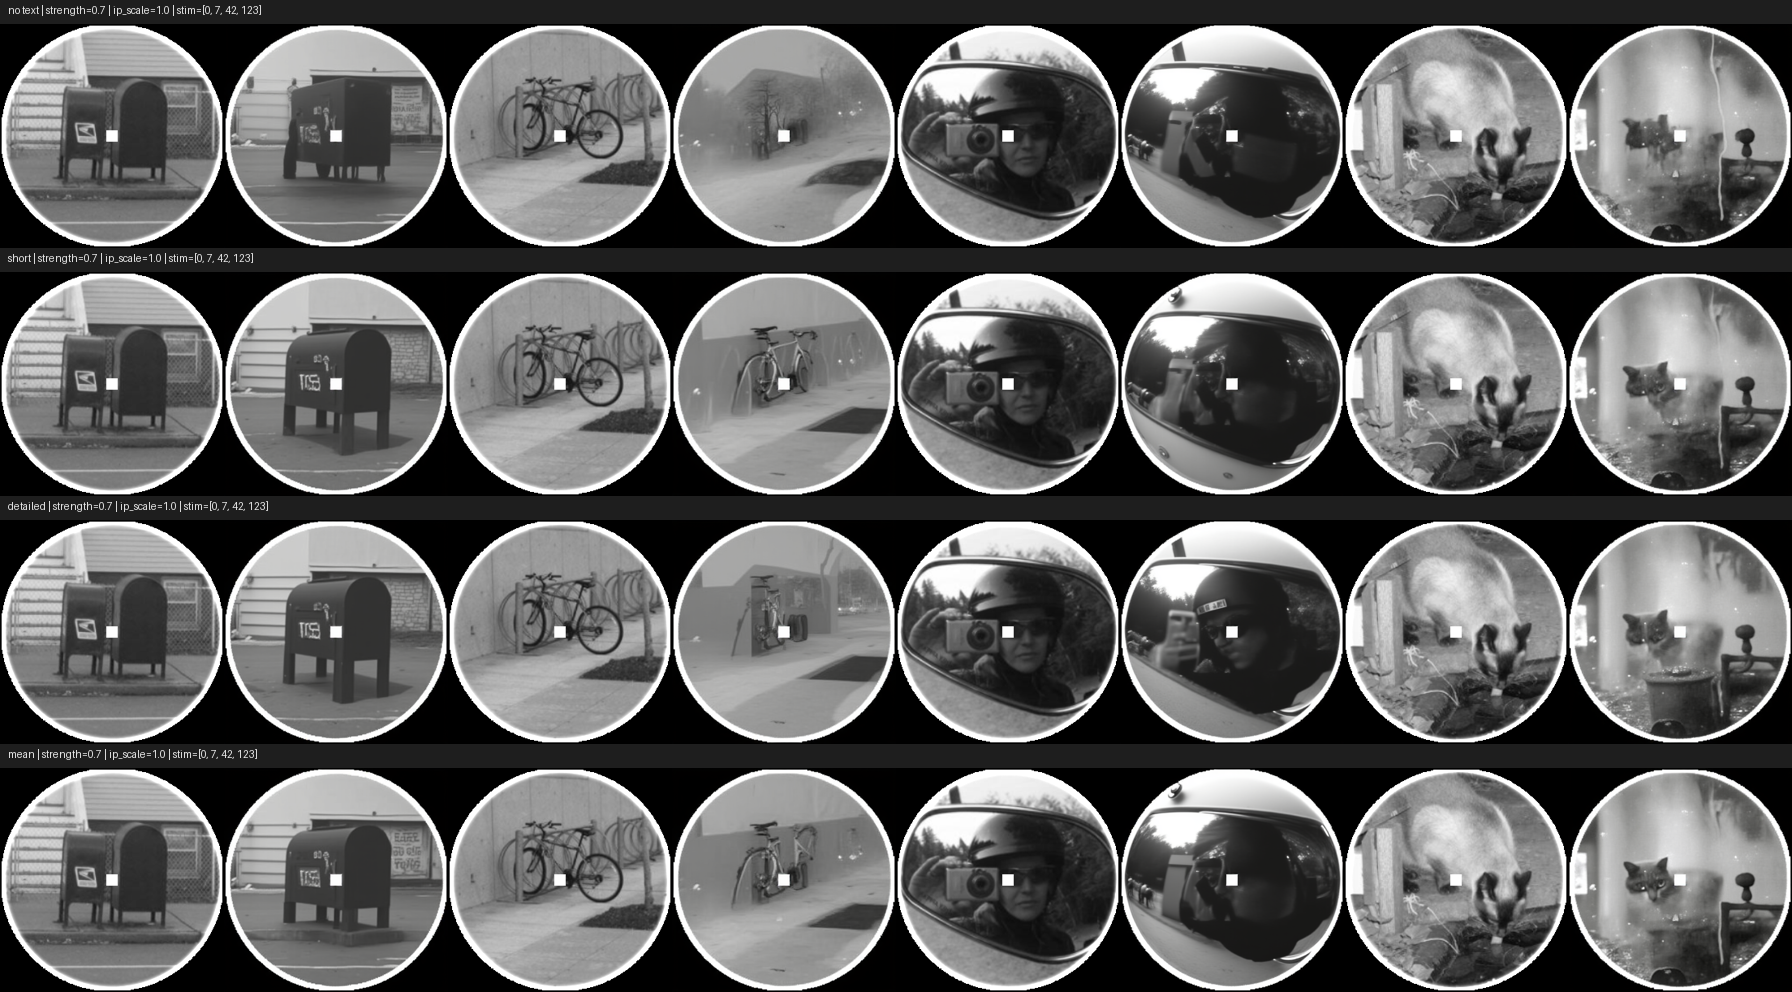

In [11]:
TEXT_STRENGTH = 0.7
TEXT_STEPS = 20
TEXT_SEED = 0

# (cond_name, clip_embeds, t5_embeds, ip_scale)
conditions = [
    ("no text",  None,         None,      1.0),
    ("short",    clip_short,   t5_short,  1.0),
    ("detailed", clip_detailed, t5_detailed, 1.0),
    ("mean",     clip_mean,    t5_mean,   1.0),
]

text_grids = []
print(f"{'condition':>12} {'stim':>6} {'MSE':>10}")
for cond_name, clip_all, t5_all, ip_scale in conditions:
    pairs = []
    for idx, pil, emb in zip(STIM_INDICES, stim_pils, stim_embs):
        clip_e = clip_all[idx].unsqueeze(0) if clip_all is not None else None
        t5_e   = t5_all[idx].unsqueeze(0)   if t5_all   is not None else None
        rec = generate_img2img(
            pipe, image_proj, pil, emb,
            strength=TEXT_STRENGTH,
            height=IMAGE_SIZE, width=IMAGE_SIZE,
            num_inference_steps=TEXT_STEPS,
            guidance_scale=3.5,
            ip_adapter_scale=ip_scale,
            prompt_embeds=t5_e,
            pooled_prompt_embeds=clip_e,
            seed=TEXT_SEED,
            aperture_composite=True,
            show_progress=False,
        )
        mse = masked_lum_mse(pil, rec)
        print(f"{cond_name:>12} {idx:>6} {mse:>10.2f}")
        pairs.append((pil, rec))
    label = f"{cond_name} | strength={TEXT_STRENGTH} | ip_scale={ip_scale} | stim={STIM_INDICES}"
    text_grids.append(make_grid(pairs, label, size=224))

full_text = Image.new("RGB", (text_grids[0].width, sum(g.height for g in text_grids)), (20, 20, 20))
y = 0
for g in text_grids:
    full_text.paste(g, (0, y))
    y += g.height
full_text

## SigLIP embedding contribution

Same four text conditions but now also sweeping whether the SigLIP embedding (IP-Adapter) is on or off. This isolates the contribution of each conditioning path independently.

condition                stim        MSE


no text, no siglip          0     310.85
no text, no siglip          7     295.23
no text, no siglip         42     376.49
no text, no siglip        123     556.30
no text, siglip             0     269.87
no text, siglip             7     245.40
no text, siglip            42     336.23
no text, siglip           123     445.00
short, siglip               0     270.57
short, siglip               7     233.97
short, siglip              42     339.70
short, siglip             123     445.96
detailed, siglip            0     276.50
detailed, siglip            7     246.35
detailed, siglip           42     332.43
detailed, siglip          123     413.93
mean, siglip                0     274.67
mean, siglip                7     245.02
mean, siglip               42     354.34
mean, siglip              123     473.73


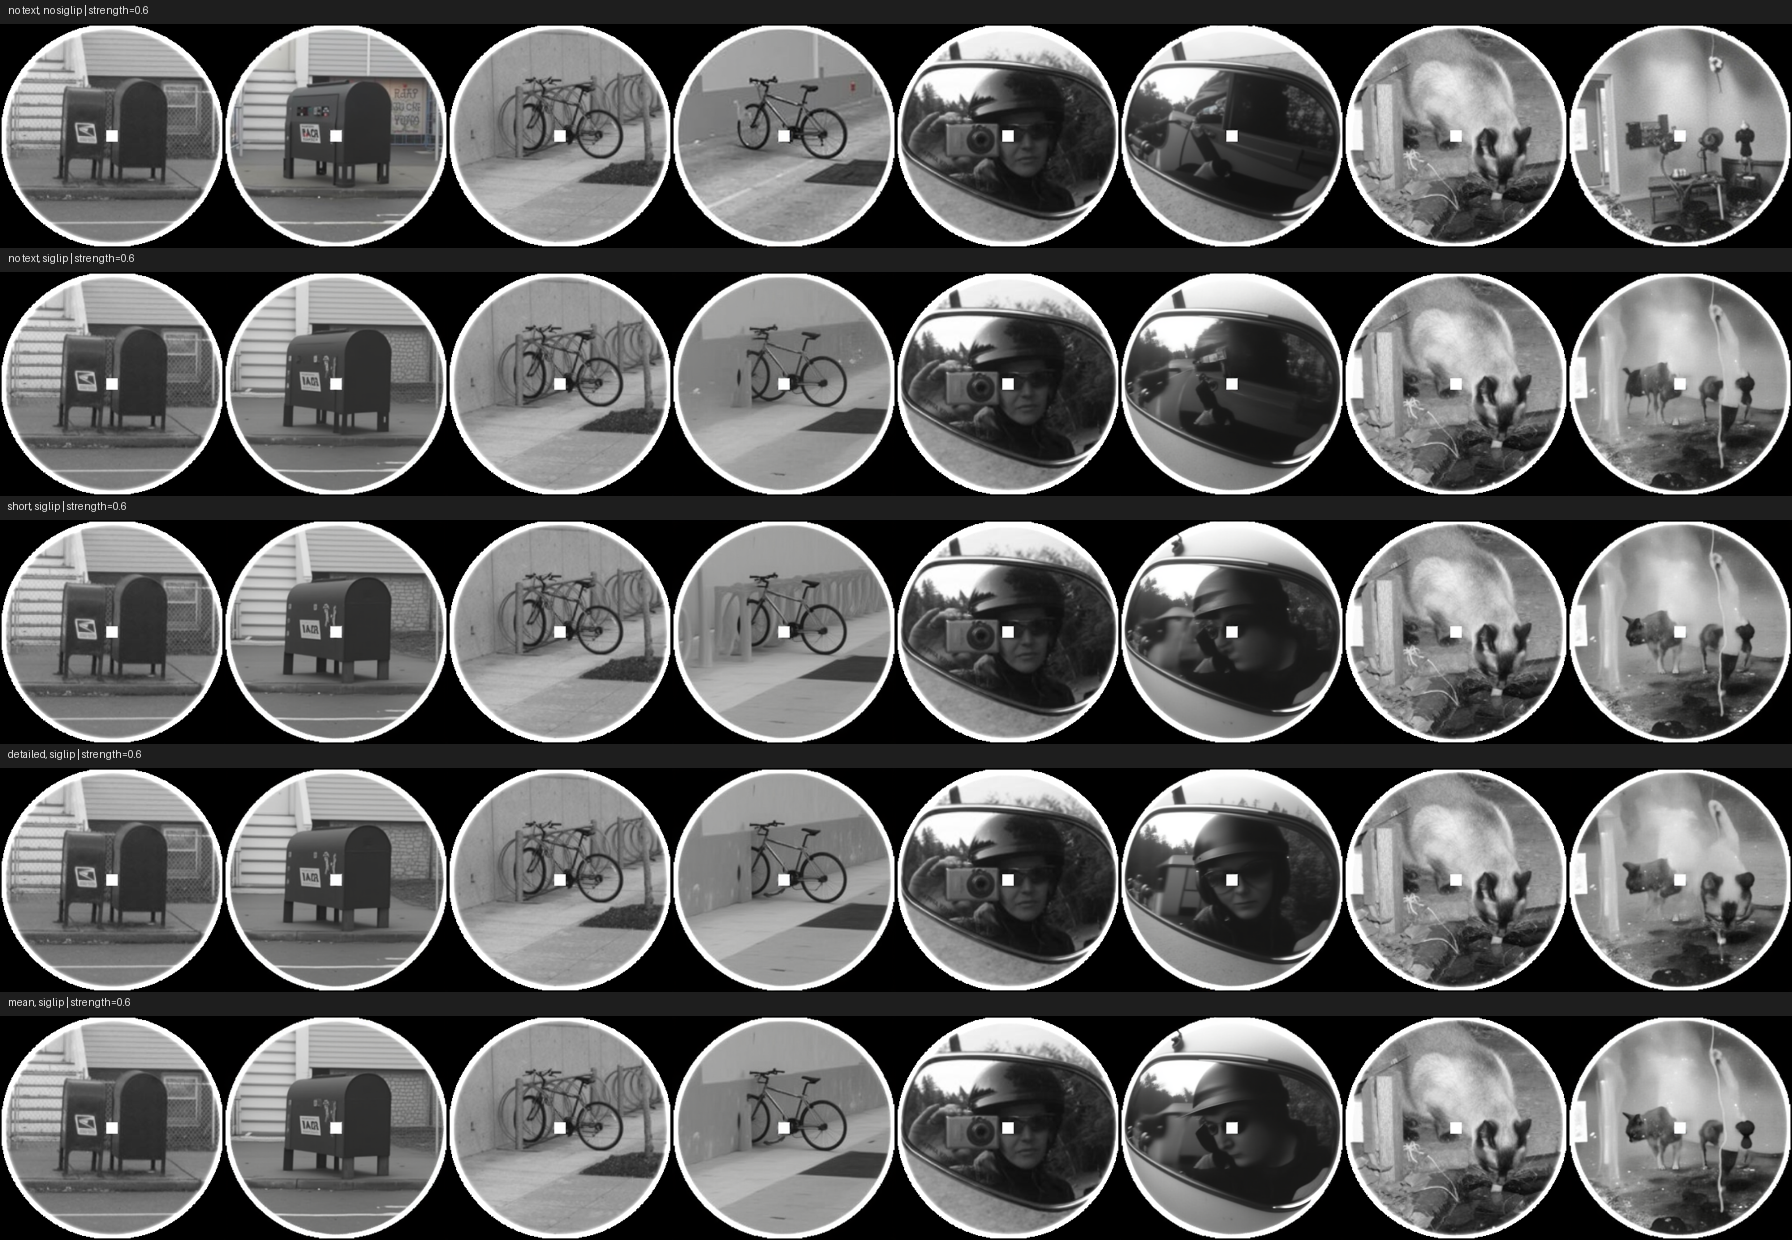

In [13]:
SIGLIP_STRENGTH = 0.6
SIGLIP_STEPS = 20
SIGLIP_SEED = 0

# (cond_name, clip_embeds, t5_embeds, use_siglip)
siglip_conditions = [
    ("no text, no siglip",   None,         None,       False),
    ("no text, siglip",      None,         None,       True),
    ("short, siglip",        clip_short,   t5_short,   True),
    ("detailed, siglip",     clip_detailed, t5_detailed, True),
    ("mean, siglip",         clip_mean,    t5_mean,    True),
]

siglip_grids = []
print(f"{'condition':<22} {'stim':>6} {'MSE':>10}")
for cond_name, clip_all, t5_all, use_siglip in siglip_conditions:
    pairs = []
    for idx, pil, emb in zip(STIM_INDICES, stim_pils, stim_embs):
        clip_e = clip_all[idx].unsqueeze(0) if clip_all is not None else None
        t5_e   = t5_all[idx].unsqueeze(0)   if t5_all   is not None else None
        rec = generate_img2img(
            pipe, image_proj, pil, emb if use_siglip else emb * 0,
            strength=SIGLIP_STRENGTH,
            height=IMAGE_SIZE, width=IMAGE_SIZE,
            num_inference_steps=SIGLIP_STEPS,
            guidance_scale=3.5,
            ip_adapter_scale=1.0 if use_siglip else 0.0,
            prompt_embeds=t5_e,
            pooled_prompt_embeds=clip_e,
            seed=SIGLIP_SEED,
            aperture_composite=True,
            show_progress=False,
        )
        mse = masked_lum_mse(pil, rec)
        print(f"{cond_name:<22} {idx:>6} {mse:>10.2f}")
        pairs.append((pil, rec))
    label = f"{cond_name} | strength={SIGLIP_STRENGTH}"
    siglip_grids.append(make_grid(pairs, label, size=224))

full_siglip = Image.new("RGB", (siglip_grids[0].width, sum(g.height for g in siglip_grids)), (20, 20, 20))
y = 0
for g in siglip_grids:
    full_siglip.paste(g, (0, y))
    y += g.height
full_siglip

## What to look for

- **VAE roundtrip MSE**: should be small (tens of units on a 0–255 scale). If this is huge, the grayscale-luminance encoding is broken.
- **Recovery sweep**: at low strength (0.3) recovery should be near-perfect regardless of `ip_scale` because the init latent dominates. At high strength (0.9) the init is almost pure noise, so recovery depends heavily on `ip_scale` — this is where the adapter's contribution becomes visible.
- **ip_scale=0 vs ip_scale=1** at `strength=0.7`: the difference between these is exactly what the InstantX adapter is doing. If they look identical, the adapter isn't being applied (check `set_ip_adapter_scale`).
- **Aperture OFF vs ON**: with OFF, the untrained ring should drift with the adapter; with ON it should match the original. If ON doesn't match the original outside the ring, the compositing is broken.
- **Masked MSE table**: at `ip_scale=1.0`, MSE should be non-increasing as strength decreases. The adapter should reduce MSE compared to `ip_scale=0.0` at the same strength — if it doesn't, the adapter is adding noise rather than information.